## Code Example 3.2 (o) Setup and Dependencies

### Short Description
This code implements a hybrid AI pipeline that combines **local computer vision** (via PyTorch) with **cloud-based LLM reasoning** using DeepSeek's API. It demonstrates transfer learning for image classification enhanced by **agentic LLM consultation**, creating a feedback loop between visual feature learning and semantic reasoning.

### Key Libraries Used
- **torch & torchvision:** Core deep learning framework for CNN-based computer vision  
- **PIL & matplotlib:** Image loading, preprocessing, and visualization  
- **requests & json:** HTTP communication with DeepSeek’s cloud API  
- **dotenv & os:** Secure management of API keys and environment configuration  

## Code Logic and Flow
### High-Level Overview
The script builds a **two-part hybrid system**:  
1) A **local ResNet-based vision model** for transfer learning, and  
2) An **LLM agent** (DeepSeek) that provides analytical insights during the workflow.  

This architecture enables the agent to combine statistical visual learning with semantic understanding, illustrating how multimodal agentic systems adapt and improve through cross-domain reasoning.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Environment Setup] --> B{GPU Available?};
    B -->|Yes| C[Configure CUDA Device];
    B -->|No| D[Use CPU];
    C --> E[Initialize Vision Model];
    D --> E;
    E --> F[Load/Process Image Data];
    F --> G[Train Local Model];
    G --> H[Generate Analysis Prompt];
    H --> I[Query DeepSeek API];
    I --> J{API Success?};
    J -->|Yes| K[Parse LLM Insights];
    J -->|No| L[Return Error];
    K --> M[Display Hybrid Results];
    L --> M;
    M --> N[End: Combined Learning];

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style C fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style D fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style E fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style F fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style G fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style H fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style I fill:#e8f5e9,stroke:#81a684,stroke-width:2px
    style J fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style K fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style L fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style M fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style N fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
```

## Step-by-Step Code Breakdown
### Step 1: Environment and Device Configuration
- Loads environment variables securely using `dotenv` to protect sensitive API keys  
- Detects available computation hardware (GPU via CUDA or CPU fallback)  
- If GPU is available, reports device name and memory capacity for planning  
- Sets the PyTorch device context so all tensors and models run on the chosen hardware  

### Step 2: DeepSeek API Client Setup
- Defines the DeepSeek API endpoint for chat completions  
- Implements `query_deepseek()`, a wrapper to manage HTTP requests  
- Formats the request payload according to DeepSeek's API schema  
- Includes structured error handling for network/API failures  
- Allows control over output randomness and length through model parameters  

### Step 3: LLM Agent Integration Test
- Sends a sample transfer learning query to ensure the LLM connection is working  
- Validates that the hybrid architecture can communicate with the cloud agent  
- Displays the LLM’s explanatory response as confirmation  
- Demonstrates how natural-language reasoning can augment the local model workflow  

### Connecting to the Lecture
- **Agentic AI Principles:** Shows how autonomous components (the LLM) observe inputs and generate actions (insights) to assist the learning process  
- **Hybrid Architecture Pattern:** Combines specialized local computation with cloud-based general reasoning  
- **Latency-Aware Design:** LLM calls are intentional and limited, aligning with best practices for agentic performance  
- **Error Propagation Management:** Robust API handling prevents failures from disrupting the local CV pipeline  
- **Prompt Engineering Application:** Uses structured prompts to extract actionable, relevant insights from the LLM  
- **Resource Optimization:** GPU detection and memory checks reflect real-world deployment strategies for constrained environments  


In [ ]:
# 1. Setup and Dependencies

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from dotenv import load_dotenv
import requests
import json
import copy

load_dotenv()
DEEPSEEK_API_KEY = os.getenv('DEEPSEEK_API_KEY')

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"Available GPU Memory: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")


# 2. Configuration for DeepSeek API

DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

def query_deepseek(prompt, max_tokens=500):
    """Query DeepSeek API for transfer learning insights"""
    headers = {
        "Authorization": f"Bearer {DEEPSEEK_API_KEY}",
        "Content-Type": "application/json"
    }

    data = {
        "model": "deepseek-chat",
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": max_tokens,
        "temperature": 0.7
    }

    response = requests.post(DEEPSEEK_API_URL, headers=headers, json=data)
    if response.status_code == 200:
        return response.json()['choices'][0]['message']['content']
    else:
        return f"Error: {response.status_code} - {response.text}"

test_response = query_deepseek("Explain in 2 sentences why transfer learning is essential for computer vision tasks with limited data.")
print("DeepSeek API Response:")
print(test_response)

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda
GPU: Tesla T4
Total GPU Memory: 14.56 GB
Available GPU Memory: 14.56 GB
DeepSeek API Response:
Error: 401 - {"error":{"message":"Authentication Fails, Your api key: None is invalid","type":"authentication_error","param":null,"code":"invalid_request_error"}}


## Code Example 3.2 (i) Creating a **synthetic 5-class flower image dataset** for computer vision experiments

### Short Description
This code block creates a **synthetic 5-class flower image dataset** for computer vision experiments and demonstrates agentic AI by querying an LLM (DeepSeek) for strategic insights on transfer learning approaches. It highlights how synthetic data can accelerate experimentation while external intelligence guides model-selection decisions.

### Key Libraries Used
- **numpy:** Numerical operations and array manipulation for generating synthetic images  
- **PIL (Pillow):** Image creation and saving functionality  
- **os:** Directory creation and file system management  

## Code Logic and Flow
### High-Level Overview
This section builds a complete synthetic data pipeline by programmatically generating labeled flower images, then consulting an LLM agent for expert guidance on transfer learning strategies. It illustrates how agentic systems integrate automated dataset creation with high-level reasoning provided by external LLMs.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Dataset Creation] --> B[Define Flower Classes];
    B --> C[Create Directory Structure];
    C --> D[Define Color Schemes per Class];
    D --> E{For Each Class};
    E --> F{For Each Sample};
    F --> G[Initialize Blank Image];
    G --> H[Fill with Base Color];
    H --> I[Generate Circular Flower Pattern];
    I --> J[Save Image to Class Folder];
    J --> K{More Samples?};
    K -->|Yes| F;
    K -->|No| L{More Classes?};
    L -->|Yes| E;
    L -->|No| M[Dataset Complete];
    M --> N[Formulate Transfer Learning Prompt];
    N --> O[Query DeepSeek API];
    O --> P[Receive Strategy Insights];
    P --> Q[End: Data + Strategy Ready];

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style C fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style D fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style E fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style F fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style G fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style H fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style I fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style J fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style K fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style L fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style M fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style N fill:#e8f5e9,stroke:#81a684,stroke-width:2px
    style O fill:#e8f5e9,stroke:#81a684,stroke-width:2px
    style P fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style Q fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
```

## Step-by-Step Code Breakdown
### Step 1: Synthetic Dataset Generation
- Defines **five flower classes**: rose, daisy, tulip, sunflower, orchid  
- Creates a structured dataset directory following ML conventions  
- Implements **class-specific color schemes** so each flower type has consistent but varied coloration  
- Generates synthetic images using:  
  - A colored background  
  - A circular "flower" region with slightly different color distributions  
- Introduces controlled randomness to create sample diversity while retaining class identity  
- Saves all generated samples as JPEG images with organized naming patterns  

### Step 2: LLM-Guided Strategy Formulation
- Constructs a focused prompt asking the DeepSeek LLM to compare **feature extraction vs. fine-tuning**  
- Requests practical guidance on when to use each transfer learning method  
- Sets a word limit to ensure concise, actionable recommendations  
- Demonstrates how agentic systems call upon LLM “consultants” to guide workflow decisions at critical points  

### Connecting to the Lecture
- **Synthetic Data for Rapid Prototyping:** Shows how artificially generated datasets solve the cold-start problem  
- **Agentic Decision Support:** LLM acts as a strategic advisor within the AI pipeline  
- **Prompt Engineering for Specificity:** Uses targeted prompts to extract relevant, constrained insights  
- **Modular Agentic Architecture:** Separates deterministic data generation from probabilistic reasoning  
- **Just-in-Time Learning:** LLM guidance is requested precisely when strategic decision-making is needed  
- **Bias Awareness:** Highlights how synthetic data structure influences downstream model behavior  
- **Human-AI Collaboration Pattern:** Demonstrates shared control between human-defined tasks and AI-generated expertise  


In [ ]:
# 3. Create Synthetic Flower Dataset and Understanding Transfer Learning Concepts

print("\n" + "="*70)
print("CREATING SYNTHETIC 5-CLASS FLOWER DATASET")
print("="*70)

def create_flower_dataset(num_samples_per_class=100):
    """Create synthetic flower images for 5 classes"""
    flower_classes = ['rose', 'daisy', 'tulip', 'sunflower', 'orchid']

    for flower_class in flower_classes:
        os.makedirs(f'flower_data/{flower_class}', exist_ok=True)

    color_schemes = {
        'rose': [(200, 50, 50), (180, 30, 30)],
        'daisy': [(255, 255, 200), (240, 240, 180)],
        'tulip': [(220, 100, 150), (200, 80, 130)],
        'sunflower': [(255, 200, 50), (240, 180, 30)],
        'orchid': [(180, 100, 200), (160, 80, 180)]
    }

    for flower_class in flower_classes:
        for i in range(num_samples_per_class):
            img = np.zeros((224, 224, 3), dtype=np.uint8)
            color1, color2 = color_schemes[flower_class]

            for c in range(3):
                img[:, :, c] = np.random.randint(color1[c]-20, color2[c]+20, (224, 224))

            center_x, center_y = 112, 112
            radius = np.random.randint(40, 60)
            y, x = np.ogrid[:224, :224]
            mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2
            img[mask] = [min(255, c + 30) for c in color1]

            Image.fromarray(img).save(f'flower_data/{flower_class}/img_{i}.jpg')

    print(f"Created {num_samples_per_class * len(flower_classes)} synthetic flower images")
    print(f"Classes: {flower_classes}")
    return flower_classes

flower_classes = create_flower_dataset(100)

transfer_learning_insight = query_deepseek(
    "Explain the difference between feature extraction and fine-tuning in transfer learning. "
    "When should each approach be used? Keep it under 150 words."
)
print("\nDeepSeek Insight on Transfer Learning:")
print(transfer_learning_insight)


CREATING SYNTHETIC 5-CLASS FLOWER DATASET
Created 500 synthetic flower images
Classes: ['rose', 'daisy', 'tulip', 'sunflower', 'orchid']

DeepSeek Insight on Transfer Learning:
Error: 401 - {"error":{"message":"Authentication Fails, Your api key: None is invalid","type":"authentication_error","param":null,"code":"invalid_request_error"}}


## Code Example 3.2 (ii) Loading a **pre-trained ResNet-50** model and constructs a complete data preprocessing pipeline for Transfer Learning

### Short Description
This code loads a **pre-trained ResNet-50** model and constructs a complete data preprocessing pipeline for transfer learning. It demonstrates how to integrate foundational vision models with custom datasets using engineered transformations that support effective agentic AI training workflows.

### Key Libraries Used
- **torchvision.models:** Access to pretrained architectures (ResNet-50)  
- **torchvision.transforms:** Image augmentation and normalization utilities  
- **torch.utils.data:** Dataset loading, splitting, batching tools  
- **copy:** Deep copying of dataset subsets to avoid unintended side effects  

## Code Logic and Flow
### High-Level Overview
This section builds the core infrastructure for transfer learning by initializing a powerful pretrained model and constructing dual transformation pipelines for training and validation. It establishes a clean separation between prior visual knowledge (ResNet-50) and task-specific flower data, forming a foundational workflow for agentic AI systems that adapt general-purpose models to specialized tasks.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Model & Data Setup] --> B[Load Pre-trained ResNet-50];
    B --> C[Analyze Model Architecture];
    C --> D[Define Training Transforms];
    D --> E[Define Validation Transforms];
    E --> F[Load Flower Dataset];
    F --> G[Split Dataset 80/20];
    G --> H[Apply Training Transforms];
    H --> I[Apply Validation Transforms];
    I --> J[Create Training DataLoader];
    J --> K[Create Validation DataLoader];
    K --> L[Display Dataset Statistics];
    L --> M[End: Ready for Training];
    
    subgraph Data Augmentation Pipeline
        D --> D1[Resize to 256x256];
        D1 --> D2[Random 224x224 Crop];
        D2 --> D3[Random Horizontal Flip];
        D3 --> D4[Color Jitter Augmentation];
        D4 --> D5[Convert to Tensor];
        D5 --> D6[Normalize with ImageNet Stats];
    end
    
    subgraph Validation Pipeline
        E --> E1[Resize to 224x224];
        E1 --> E2[Convert to Tensor];
        E2 --> E3[Normalize with ImageNet Stats];
    end

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style C fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style D fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style E fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style F fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style G fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style H fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style I fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style J fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style K fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style L fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style M fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
    style D1 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style D2 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style D3 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style D4 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style D5 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style D6 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E1 fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
    style E2 fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
    style E3 fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
```

## Step-by-Step Code Breakdown
### Step 1: Pre-trained Model Loading and Analysis
- Loads **ResNet-50 with ImageNet1K_V1** pretrained weights  
- Computes and prints the total parameter count (~25M parameters)  
- Iterates through model components to reveal architectural organization  
- Highlights how pretrained weights encode broad visual priors that will transfer to flower classification  

### Step 2: Data Transformation Pipeline Creation
#### Training Pipeline
- Applies spatial transformations such as **resize** and **random crop**  
- Adds augmentation like **horizontal flips** and **color jitter** to increase diversity  
- Converts images to tensors and applies **ImageNet normalization** for compatibility with pretrained weights  

#### Validation Pipeline
- Uses deterministic preprocessing (fixed resize) for consistent evaluation  
- Applies the same ImageNet normalization as training  
- Removes randomness to ensure fair comparison across epochs  

### Step 3: Dataset Organization and Loading
- Loads the synthetic flower dataset via **ImageFolder**, inferring class labels automatically  
- Splits data into **80% training** and **20% validation**  
- Applies different transform pipelines to training vs. validation subsets  
- Constructs **DataLoader** objects with batching and (for training) shuffling  
- Prints dataset statistics for debugging and transparency  

### Connecting to the Lecture
- **Foundation Model Utilization:** Demonstrates leveraging pretrained models instead of training from scratch  
- **Transfer Learning Mechanics:** Shows practical application of reusing visual features learned from ImageNet  
- **Data Augmentation as Regularization:** Implements augmentation techniques discussed for preventing overfitting  
- **Train/Val Disconnect Management:** Uses separate pipelines to avoid inconsistencies during evaluation  
- **Batch Processing Optimization:** Applies efficient DataLoader configuration reflecting lecture guidance  
- **Transparency and Debugging:** Reporting of parameters and dataset composition aligns with agentic system transparency principles  
- **Normalization Consistency:** Ensures distribution alignment with pretrained models, as emphasized in transfer learning theory  


In [ ]:
# 4. Load Pre-trained ResNet-50 and Prepare Data

print("\n" + "="*70)
print("LOADING PRE-TRAINED RESNET-50 AND PREPARING DATA")
print("="*70)

resnet50_pretrained = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
print("Pre-trained ResNet-50 loaded successfully")
print(f"Total parameters: {sum(p.numel() for p in resnet50_pretrained.parameters()):,}")

print("\nResNet-50 Architecture Overview:")
for name, module in resnet50_pretrained.named_children():
    num_params = sum(p.numel() for p in module.parameters())
    print(f"{name:15} | {module.__class__.__name__:20} | Parameters: {num_params:,}")

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImageFolder('flower_data', transform=transform_train)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

val_dataset.dataset = copy.deepcopy(dataset)
val_dataset.dataset.transform = transform_val

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"\nDataset Statistics:")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(dataset.classes)}")
print(f"Classes: {dataset.classes}")


LOADING PRE-TRAINED RESNET-50 AND PREPARING DATA
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]


Pre-trained ResNet-50 loaded successfully
Total parameters: 25,557,032

ResNet-50 Architecture Overview:
conv1           | Conv2d               | Parameters: 9,408
bn1             | BatchNorm2d          | Parameters: 128
relu            | ReLU                 | Parameters: 0
maxpool         | MaxPool2d            | Parameters: 0
layer1          | Sequential           | Parameters: 215,808
layer2          | Sequential           | Parameters: 1,219,584
layer3          | Sequential           | Parameters: 7,098,368
layer4          | Sequential           | Parameters: 14,964,736
avgpool         | AdaptiveAvgPool2d    | Parameters: 0
fc              | Linear               | Parameters: 2,049,000

Dataset Statistics:
Training samples: 400
Validation samples: 100
Number of classes: 5
Classes: ['daisy', 'orchid', 'rose', 'sunflower', 'tulip']


## Code Example 3.2 (iii) Implementing the **feature extraction** approach to transfer learning

### Short Description
This code implements the **feature extraction** approach to transfer learning by freezing all pre-trained layers of ResNet-50 and training only a newly added classifier head. It preserves foundational visual knowledge while adapting to a new 5-class flower classification task with minimal parameter updates.

### Key Libraries Used
- **torch.nn:** Neural network layers, activations, loss functions  
- **torch.optim:** Gradient-based optimization algorithms  
- **torchvision.models:** Pre-trained ResNet-50 architecture  

## Code Logic and Flow
### High-Level Overview
This section implements the first strategy from the earlier LLM consultation: **feature extraction**. All convolutional layers of the pre-trained model are frozen to retain their learned representations, and the final classification layer is replaced with a custom multi-layer perceptron for 5-class recognition. This yields an efficient training setup ideal for limited-data scenarios while leveraging the rich feature extraction abilities of the base model.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Feature Extraction Model] --> B[Load Pre-trained ResNet-50];
    B --> C[Freeze All Base Parameters];
    C --> D[Analyze Original FC Layer];
    D --> E[Replace with Custom Classifier];
    
    subgraph Custom Classifier Head
        E --> E1[Linear: num_features → 512];
        E1 --> E2[ReLU Activation];
        E2 --> E3[Dropout 30%];
        E3 --> E4[Linear: 512 → 256];
        E4 --> E5[ReLU Activation];
        E5 --> E6[Dropout 30%];
        E6 --> E7[Linear: 256 → 5];
    end
    
    E --> F[Move Model to Device GPU/CPU];
    F --> G[Calculate Trainable vs Frozen Parameters];
    G --> H[Define CrossEntropy Loss];
    H --> I[Configure Optimizer for FC Only];
    I --> J[Display Strategy Summary];
    J --> K[End: Model Ready for Training];

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style C fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style D fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style E fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style E1 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E2 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E3 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E4 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E5 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E6 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E7 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style F fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style G fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style H fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style I fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style J fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style K fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
```

## Step-by-Step Code Breakdown
### Step 1: Model Initialization and Parameter Freezing
- Loads a fresh instance of **ResNet-50 with ImageNet weights**  
- Iterates over all model parameters and sets **requires_grad = False**  
- Converts the convolutional backbone into a fixed 2048-dimensional **feature extractor**  
- Retains learned representations for edges, textures, shapes, and high-level object parts  

### Step 2: Custom Classifier Head Design
- Identifies the original ResNet-50 FC layer input size (**2048 features**)  
- Replaces it with a **Sequential classifier**:  
  `2048 → 512 → 256 → 5`  
- Adds **ReLU** activations for non-linearity  
- Uses **Dropout (30%)** to mitigate overfitting on the small synthetic dataset  
- Forms a compact bottleneck architecture mapping general ImageNet features to flower categories  

### Step 3: Training Configuration and Strategy Analysis
- Moves the updated model to **GPU or CPU** as available  
- Prints statistics on **frozen vs. trainable** parameters to highlight efficiency  
- Initializes **CrossEntropyLoss** for multi-class classification  
- Configures **Adam optimizer** to update only the new classifier head (`model.fc.parameters()`)  
- Notes the strategic rationale: faster training and stable performance when data is limited  

### Connecting to the Lecture
- **Parameter Efficiency:** Demonstrates updating only a small subset of parameters—key to efficient fine-tuning in constrained environments  
- **Knowledge Preservation:** Uses the frozen-encoder strategy to retain foundational visual features  
- **Overfitting Mitigation:** Dropout directly addresses small-dataset generalization challenges  
- **Strategic Trade-offs:** Shows the balance between training speed and ultimate accuracy in transfer learning  
- **Modular Architecture:** Implements the "frozen encoder + trainable decoder" pattern common in agentic AI workflows  
- **Transparency in Design:** Parameter statistics support explainable system design principles  
- **Gradient Flow Control:** Freezing parameters illustrates deliberate control over backpropagation for efficient optimization  


In [ ]:
# 5. Feature Extraction Approach - Freeze All Layers

print("\n" + "="*70)
print("APPROACH 1: FEATURE EXTRACTION (FREEZE ALL LAYERS)")
print("="*70)

model_feature_extraction = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model_feature_extraction.parameters():
    param.requires_grad = False

num_features = model_feature_extraction.fc.in_features
model_feature_extraction.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 5)
)

model_feature_extraction = model_feature_extraction.to(device)

trainable_params = sum(p.numel() for p in model_feature_extraction.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model_feature_extraction.parameters() if not p.requires_grad)

print(f"Frozen parameters: {frozen_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {100 * trainable_params / (trainable_params + frozen_params):.2f}%")

criterion = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(model_feature_extraction.fc.parameters(), lr=0.001)

print("\nFeature Extraction Strategy:")
print("- All convolutional layers frozen (preserve ImageNet features)")
print("- Only final classifier layers trainable")
print("- Fast training, suitable for small datasets")
print("- Learning rate: 0.001")


APPROACH 1: FEATURE EXTRACTION (FREEZE ALL LAYERS)
Frozen parameters: 23,508,032
Trainable parameters: 1,181,701
Percentage trainable: 4.79%

Feature Extraction Strategy:
- All convolutional layers frozen (preserve ImageNet features)
- Only final classifier layers trainable
- Fast training, suitable for small datasets
- Learning rate: 0.001


## Code Example 3.2 (iv) Implementing the **partial fine-tuning transfer learning** approach

### Short Description
This code implements the partial fine-tuning transfer learning approach by selectively unfreezing the **final convolutional block (layer4)** while keeping earlier layers frozen. It demonstrates granular control over parameter updates and consults an LLM for expert guidance on hyperparameter strategy.

### Key Libraries Used
- **torch.nn**: Neural network layers and activation functions for custom classifier design  
- **torch.optim**: Optimization algorithms with parameter group configuration capabilities  
- **Custom query_deepseek function**: Engages the LLM agent for domain-specific hyperparameter insights  

## Code Logic and Flow
### High-Level Overview
This section implements an intermediate transfer learning strategy that balances between **feature extraction** and **full fine-tuning**. The approach selectively unfreezes only the deepest convolutional block (**layer4**) while keeping earlier layers (1–3) frozen, allowing task-specific adaptation of high-level features while preserving general low-level visual representations. The implementation demonstrates sophisticated gradient flow control, differential learning rate configuration, and agentic consultation for hyperparameter tuning rationale—showcasing how agentic AI systems can make nuanced architectural decisions informed by external intelligence.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Partial Fine-Tuning Setup] --> B[Load Pre-trained ResNet-50];
    B --> C[Freeze All Parameters Initially];
    C --> D[Selectively Unfreeze Layer4];
    D --> E[Replace Classifier Head];
    E --> F[Move Model to Device];
    F --> G[Calculate Trainable vs Frozen Parameters];
    G --> H[Configure Differential Learning Rates];
    
    subgraph Gradient Flow Strategy
        C --> C1[Layer1: Frozen<br/>Edges, Textures];
        C1 --> C2[Layer2: Frozen<br/>Patterns, Shapes];
        C2 --> C3[Layer3: Frozen<br/>Object Parts];
        C3 --> D;
        D --> D1[Layer4: Trainable<br/>Task-Specific Features];
    end
    
    subgraph Learning Rate Schedule
        H --> H1[Layer4: 0.0001];
        H1 --> H2[Classifier: 0.001];
    end
    
    H --> I[Consult LLM for Strategy Rationale];
    I --> J[Display Hyperparameter Insights];
    J --> K[End: Model Ready for Training];
    
    style A fill:#e8f5e9
    style B fill:#e3f2fd
    style C fill:#fce4ec
    style D fill:#f1f8e9
    style E fill:#fff3e0
    style F fill:#e0f2f1
    style G fill:#f3e5f5
    style H fill:#e1f5fe
    style C1 fill:#ffebee
    style C2 fill:#fce4ec
    style C3 fill:#f8bbd0
    style D1 fill:#c8e6c9
    style H1 fill:#e3f2fd
    style H2 fill:#fff3e0
    style I fill:#e8eaf6
    style J fill:#ede7f6
    style K fill:#dcedc8
```

## Step-by-Step Code Breakdown
### Step 1: Selective Parameter Unfreezing Strategy
**Purpose:** Implements a hierarchical unfreezing approach that balances preservation of general features with adaptation to specific tasks.

**Initial Freezing Operations:**
- Loads a fresh ResNet-50 instance with ImageNet weights  
- Iterates through all parameters and sets **requires_grad = False** to freeze everything  
- Establishes a fully frozen baseline state  

**Selective Unfreezing Operations:**
- Targets only **layer4** parameters for unfreezing  
- Sets **requires_grad = True** for just layer4  
- Enables gradient updates for the highest-level feature representations  
- Keeps layers 1–3 frozen to preserve general visual primitives  

### Step 2: Custom Classifier and Training Configuration
**Purpose:** Creates a task-specific classifier head and configures optimization with layer-wise learning rates.

**Classifier Design Operations:**
- Extracts the 2048-dim input dimension from the original fully connected layer  
- Constructs the same sequential classifier used in previous approaches  
- Adds dropout for regularization  
- Ensures architectural consistency for fair comparison  

**Optimization Configuration Operations:**
- Creates **separate parameter groups** for layer4 and classifier  
- Assigns **LR = 0.0001** for layer4 to avoid catastrophic forgetting  
- Assigns **LR = 0.001** for classifier to support rapid adaptation  
- Demonstrates nuanced learning rate control tailored to each network part  

### Step 3: Agentic Hyperparameter Consultation
**Purpose:** Uses an LLM to justify the differential learning rate strategy.

**Key Operations:**
- Formulates a targeted prompt asking about learning rate differentials  
- Requests a concise (3-sentence) expert explanation  
- Integrates LLM reasoning into the development workflow  
- Provides conceptual clarity behind architecture-specific optimization choices  

## Connecting to the Lecture
- **Hierarchical Feature Preservation:** Implements lecture concepts of progressive layer unfreezing based on abstraction relevance.  
- **Gradient Flow Engineering:** Demonstrates controlled gradient propagation, a core optimization technique.  
- **Differential Learning Rate Application:** Practical execution of “discriminative fine-tuning” discussed in transfer learning theory.  
- **Agentic Design Pattern Integration:** Uses LLM consultation for just-in-time expert reasoning.  
- **Parameter Efficiency with Adaptation:** Balances efficiency and adaptability—midpoint between feature extraction & full fine-tuning.  
- **Architectural Transparency:** Explicit freezing/unfreezing reflects explainable architecture principles.  
- **Knowledge Hierarchy in Deep Networks:** Leverages theoretical understanding of general vs. task-specific features.  


In [ ]:
# 6. Partial Fine-Tuning Approach - Unfreeze Last Residual Block

print("\n" + "="*70)
print("APPROACH 2: PARTIAL FINE-TUNING (UNFREEZE LAYER4)")
print("="*70)

model_partial_finetune = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model_partial_finetune.parameters():
    param.requires_grad = False

for param in model_partial_finetune.layer4.parameters():
    param.requires_grad = True

num_features = model_partial_finetune.fc.in_features
model_partial_finetune.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 5)
)

model_partial_finetune = model_partial_finetune.to(device)

trainable_params = sum(p.numel() for p in model_partial_finetune.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model_partial_finetune.parameters() if not p.requires_grad)

print(f"Frozen parameters: {frozen_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {100 * trainable_params / (trainable_params + frozen_params):.2f}%")

optimizer_pf = optim.Adam([
    {'params': model_partial_finetune.layer4.parameters(), 'lr': 0.0001},
    {'params': model_partial_finetune.fc.parameters(), 'lr': 0.001}
])

print("\nPartial Fine-Tuning Strategy:")
print("- Layers 1-3 frozen (general features)")
print("- Layer 4 unfrozen (task-specific adaptation)")
print("- Classifier trainable")
print("- Different learning rates: Layer4 (0.0001), Classifier (0.001)")

partial_finetune_insight = query_deepseek(
    "Why do we use a lower learning rate for pre-trained layers compared to newly initialized layers "
    "during fine-tuning? Explain in 3 sentences."
)
print("\nDeepSeek Insight on Learning Rates:")
print(partial_finetune_insight)


APPROACH 2: PARTIAL FINE-TUNING (UNFREEZE LAYER4)
Frozen parameters: 8,543,296
Trainable parameters: 16,146,437
Percentage trainable: 65.40%

Partial Fine-Tuning Strategy:
- Layers 1-3 frozen (general features)
- Layer 4 unfrozen (task-specific adaptation)
- Classifier trainable
- Different learning rates: Layer4 (0.0001), Classifier (0.001)

DeepSeek Insight on Learning Rates:
Error: 401 - {"error":{"message":"Authentication Fails, Your api key: None is invalid","type":"authentication_error","param":null,"code":"invalid_request_error"}}


## Code Example 3.2 (v) Implementing the **full fine-tuning** transfer learning approach with **layer-wise learning rates** and a reusable training function

### Short Description
This code implements the **full fine-tuning** transfer learning approach with **layer-wise learning rates** and a reusable training function featuring detailed monitoring. It demonstrates advanced optimization techniques and systematic model evaluation for agentic AI systems.

### Key Libraries Used
- **torch.nn:** Neural network layers, activations, dropout  
- **torch.optim:** Adam optimizer with parameter-group configurations  
- **torch:** Tensor operations, GPU handling, gradient computation  

## Code Logic and Flow
### High-Level Overview
This section performs full fine-tuning of a pre-trained ResNet-50 model where **all layers are trainable**, but learning rates are carefully calibrated across network depth. A sophisticated optimization scheme assigns smaller learning rates to earlier layers and larger rates to deeper and newly added layers. A modular, fully instrumented training loop manages forward/backward passes, validation, memory handling, and metric tracking, demonstrating how agentic systems adapt models deeply while avoiding catastrophic forgetting.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Full Fine-Tuning Setup] --> B[Load Pre-trained ResNet-50];
    B --> C[Replace Classifier Head];
    C --> D[Move to Device GPU/CPU];
    D --> E[Configure Layer-Wise LR Schedule];
    E --> F[Define Training Function];
    
    subgraph Parameter Group Strategy
        E --> E1[Layer1: LR=1e-5];
        E1 --> E2[Layer2: LR=5e-5];
        E2 --> E3[Layer3: LR=1e-4];
        E3 --> E4[Layer4: LR=1e-4];
        E4 --> E5[Classifier: LR=1e-3];
    end
    
    subgraph Training Loop
        F --> F1[Initialize Metrics Arrays];
        F1 --> F2{For Each Epoch};
        F2 --> F3[Training Phase];
        F3 --> F3a[Forward Pass];
        F3a --> F3b[Loss Computation];
        F3b --> F3c[Backward Pass];
        F3c --> F3d[Optimizer Step];
        F3 --> F4[Validation Phase];
        F4 --> F4a[Forward Pass No Grad];
        F4a --> F4b[Loss Computation];
        F2 --> F5[Calculate Epoch Metrics];
        F5 --> F6[Display Progress];
        F6 --> F7[Clear Memory Cache];
        F7 --> F8{More Epochs?};
        F8 -->|Yes| F2;
        F8 -->|No| F9[Return Training History];
    end
    
    F9 --> G[End: Training System Ready];

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style C fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style D fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style E fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style E1 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E2 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E3 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E4 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style E5 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style F fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style F1 fill:#fce4ec,stroke:#c48b9f,stroke-width:1px
    style F2 fill:#f3e5f5,stroke:#9575b3,stroke-width:1px
    style F3 fill:#fff4e6,stroke:#d4a373,stroke-width:1px
    style F3a fill:#e3f2fd,stroke:#7ba3cc,stroke-width:1px
    style F3b fill:#e3f2fd,stroke:#7ba3cc,stroke-width:1px
    style F3c fill:#e3f2fd,stroke:#7ba3cc,stroke-width:1px
    style F3d fill:#e3f2fd,stroke:#7ba3cc,stroke-width:1px
    style F4 fill:#fff9e6,stroke:#d9c27a,stroke-width:1px
    style F4a fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
    style F4b fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
    style F5 fill:#fce4ec,stroke:#c48b9f,stroke-width:1px
    style F6 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style F7 fill:#fff4e6,stroke:#d4a373,stroke-width:1px
    style F8 fill:#f3e5f5,stroke:#9575b3,stroke-width:1px
    style F9 fill:#e3f2fd,stroke:#7ba3cc,stroke-width:1px
    style G fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
```

## Step-by-Step Code Breakdown
### Step 1: Model Configuration for Full Fine-Tuning
- Loads a fresh **ResNet-50** with ImageNet weights  
- Replaces the final classifier with the custom **5-class flower classifier**  
- Leaves all parameters **trainable** (`requires_grad=True`)  
- Computes & prints total trainable parameters (~25M)  

### Step 2: Layer-Wise Learning Rate Configuration
- Creates optimizer parameter groups with **differential learning rates**  
- Assigns **1e-5** to early layers (layer1) to preserve general features  
- Assigns **5e-5** and **1e-4** to mid/deep layers (layer2–layer4)  
- Assigns **1e-3** to the new classifier head for rapid learning  
- Implements the principle: *early layers = generic features, deep layers = task-specific features*  

### Step 3: Modular Training Function Implementation
#### Training Phase
- Activates `model.train()` enabling dropout + batch norm updates  
- Performs: forward → loss → backward → optimizer step  
- Tracks training loss and accuracy  
- Uses gradient zeroing (`optimizer.zero_grad()`) to avoid accumulation  

#### Validation Phase
- Activates `model.eval()` disabling dropout & freezing batch norm stats  
- Wraps inference in `torch.no_grad()` to reduce computation  
- Computes validation loss & accuracy without updating parameters  

#### Memory Management
- Explicit deletion of intermediate tensors to free GPU memory  
- Calls `torch.cuda.empty_cache()` after each epoch  
- Demonstrates resource-aware engineering for agentic systems  

### Connecting to the Lecture
- **Differential Learning Rates:** Matches the lecture’s layer-wise adaptive learning strategies  
- **Catastrophic Forgetting Prevention:** Low LR in early layers preserves foundational knowledge  
- **Comprehensive Adaptation:** Shows full fine-tuning—highest accuracy but highest compute  
- **Systematic Evaluation:** Mirrors agentic principles of train/validation separation  
- **Resource-Aware Programming:** Explicit GPU memory handling reflects real-world constraints  
- **Modular Design:** Reusable training loop → modular agentic system architecture  
- **Transparency:** Epoch-wise metrics embody observable and interpretable agent behavior  


In [ ]:
# 7. Full Fine-Tuning Approach and Training Function

print("\n" + "="*70)
print("APPROACH 3: FULL FINE-TUNING (UNFREEZE ALL LAYERS)")
print("="*70)

model_full_finetune = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

num_features = model_full_finetune.fc.in_features
model_full_finetune.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 5)
)

model_full_finetune = model_full_finetune.to(device)

trainable_params = sum(p.numel() for p in model_full_finetune.parameters() if p.requires_grad)
print(f"All parameters trainable: {trainable_params:,}")

optimizer_ff = optim.Adam([
    {'params': model_full_finetune.layer1.parameters(), 'lr': 0.00001},
    {'params': model_full_finetune.layer2.parameters(), 'lr': 0.00005},
    {'params': model_full_finetune.layer3.parameters(), 'lr': 0.0001},
    {'params': model_full_finetune.layer4.parameters(), 'lr': 0.0001},
    {'params': model_full_finetune.fc.parameters(), 'lr': 0.001}
])

print("\nFull Fine-Tuning Strategy:")
print("- All layers trainable")
print("- Layer-wise learning rates (lower for early layers)")
print("- Layer1: 0.00001, Layer2: 0.00005, Layer3: 0.0001")
print("- Layer4: 0.0001, Classifier: 0.001")

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, model_name):
    """Train transfer learning model with detailed metrics"""
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\nTraining {model_name}...")
    print("-" * 70)

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            # Clear intermediate tensors
            del images, labels, outputs, loss

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                # Clear intermediate tensors
                del images, labels, outputs, loss

        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.2f}%")

        # Clear cache after each epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return train_losses, val_losses, train_accs, val_accs

print("\nTraining function defined and ready")


APPROACH 3: FULL FINE-TUNING (UNFREEZE ALL LAYERS)
All parameters trainable: 24,689,733

Full Fine-Tuning Strategy:
- All layers trainable
- Layer-wise learning rates (lower for early layers)
- Layer1: 0.00001, Layer2: 0.00005, Layer3: 0.0001
- Layer4: 0.0001, Classifier: 0.001

Training function defined and ready


## Code Example 3.2 (vi) Training all three transfer learning approaches (feature extraction, partial fine-tuning, full fine-tuning) and systematically compares their performance

### Short Description
This code executes training for all three transfer learning approaches (feature extraction, partial fine-tuning, full fine-tuning) and systematically compares their performance. It demonstrates **experimental methodology**, **resource management**, and **comparative analysis** in agentic AI development.

### Key Libraries Used
- Built-in Python data structures (**dict**): Store and organize experimental results for comparison  
- **torch.cuda**: Manages GPU memory allocation and cleanup operations  
- **Custom `train_model` function**: Reusable training loop defined in previous sections  

## Code Logic and Flow
### High-Level Overview
This section implements a comprehensive experimental framework that sequentially trains three different transfer learning strategies using the same dataset and training configuration, then performs a systematic comparison of their results. The workflow demonstrates rigorous scientific methodology in agentic AI development by **controlling variables** (epochs, dataset, validation splits) while systematically varying the training approach. The implementation includes careful **resource management** between experiments to ensure fair comparison without memory interference, embodying professional AI research practices.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Comparative Experiment] --> B[Define Training Epochs];
    B --> C[Initialize Results Dictionary];
    C --> D[Calculate Trainable Parameters];
    
    subgraph Experiment 1: Feature Extraction
        D --> E1[Train Feature Extraction Model];
        E1 --> F1[Store Results];
        F1 --> G1[Clear Model & Optimizer];
        G1 --> H1[Empty GPU Cache];
    end
    
    subgraph Experiment 2: Partial Fine-Tuning
        H1 --> E2[Train Partial Fine-Tuning Model];
        E2 --> F2[Store Results];
        F2 --> G2[Clear Model & Optimizer];
        G2 --> H2[Empty GPU Cache];
    end
    
    subgraph Experiment 3: Full Fine-Tuning
        H2 --> E3[Train Full Fine-Tuning Model];
        E3 --> F3[Store Results];
        F3 --> G3[Clear Model & Optimizer];
        G3 --> H3[Empty GPU Cache];
    end
    
    H3 --> I[Compile Final Results];
    I --> J[Display Comparative Metrics];
    J --> K[End: Analysis Ready];

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style C fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style D fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style E1 fill:#e3f2fd,stroke:#7ba3cc,stroke-width:1px
    style F1 fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
    style G1 fill:#fce4ec,stroke:#c48b9f,stroke-width:1px
    style H1 fill:#fff4e6,stroke:#d4a373,stroke-width:1px
    style E2 fill:#f3e5f5,stroke:#9575b3,stroke-width:1px
    style F2 fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
    style G2 fill:#fce4ec,stroke:#c48b9f,stroke-width:1px
    style H2 fill:#fff4e6,stroke:#d4a373,stroke-width:1px
    style E3 fill:#fce4ec,stroke:#c48b9f,stroke-width:1px
    style F3 fill:#e1f0f5,stroke:#7d9fb8,stroke-width:1px
    style G3 fill:#fce4ec,stroke:#c48b9f,stroke-width:1px
    style H3 fill:#fff4e6,stroke:#d4a373,stroke-width:1px
    style I fill:#e8f5e9,stroke:#81a684,stroke-width:2px
    style J fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style K fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
```

## Step-by-Step Code Breakdown
### Step 1: Experimental Setup and Baseline Measurement
**Purpose:** Establishes controlled experimental conditions and captures baseline characteristics before training begins.

**Key Operations:**
- Sets a fixed number of training epochs (8) for all approaches to ensure fair comparison  
- Initializes a results dictionary to systematically store training outcomes from all three approaches  
- Calculates and stores the number of trainable parameters for each approach before training begins  
- Captures the fundamental **complexity/efficiency trade-off** between approaches at the architectural level  

### Step 2: Sequential Training with Resource Management
**Purpose:** Executes training for each approach in sequence with careful resource cleanup between experiments.

**Feature Extraction Training:**
- Calls the reusable `train_model` function with the feature extraction model and its optimizer  
- Stores the returned training/validation losses and accuracies in the results dictionary  
- Explicitly deletes the model and optimizer objects to free memory  
- Empties the GPU cache to prevent memory interference with subsequent experiments  

**Partial Fine-Tuning Training:**
- Repeats the training process with the partial fine-tuning model (not shown in this snippet but referenced)  
- Maintains identical training conditions (same data loaders, criterion, epochs)  
- Performs the same memory cleanup to ensure independent experimental conditions  

**Full Fine-Tuning Training:**
- Executes training with the most complex model (all layers trainable with layer-wise learning rates)  
- Completes the experimental sequence with the same rigorous cleanup protocol  

### Step 3: Comparative Results Analysis
**Purpose:** Compiles and displays key performance metrics across all approaches for easy comparison.

**Key Operations:**
- Iterates through the results dictionary containing all three approaches' training histories  
- Extracts and displays the final **training accuracy** from the last epoch  
- Shows the final **validation accuracy** as the primary performance metric  
- Reports the final **validation loss** to assess model calibration and convergence  
- Presents results in a standardized format that facilitates direct comparison between approaches  

### Connecting to the Lecture
- **Controlled Experimentation:** Demonstrates the *scientific methodology for AI evaluation* discussed in lecture, where variables are controlled while systematically varying the approach under test.  
- **Resource Management Between Tasks:** The explicit memory cleanup between experiments exemplifies *resource-aware multi-agent systems* where components must clean up after themselves to prevent interference.  
- **Fair Comparison Protocol:** The consistent epoch count and dataset usage implement the *fair evaluation* principle crucial for reproducible agentic AI research.  
- **Parameter Efficiency Analysis:** The trainable parameter tracking connects to lecture discussions about *computational complexity vs. performance* trade-offs in agentic systems.  
- **Sequential Execution Pattern:** Shows a practical implementation of *sequential agent orchestration* where different AI strategies are tested one after another with clean state transitions.  
- **Results Aggregation and Comparison:** The systematic results compilation embodies the *meta-learning* concept where agentic systems can learn from the performance of different approaches.  
- **Transparent Performance Reporting:** The clear metrics display implements the *explainable AI evaluation* principle, making it easy to understand which approach works best and why.  


In [ ]:
# 8. Train All Three Approaches and Compare Results

print("\n" + "="*70)
print("TRAINING ALL THREE APPROACHES")
print("="*70)

epochs = 8

results = {}

# Save trainable parameters count before training (for later visualization)
trainable_params_comparison = {
    'Feature Extraction': sum(p.numel() for p in model_feature_extraction.parameters() if p.requires_grad),
    'Partial Fine-Tuning': sum(p.numel() for p in model_partial_finetune.parameters() if p.requires_grad),
    'Full Fine-Tuning': sum(p.numel() for p in model_full_finetune.parameters() if p.requires_grad)
}

# Train Feature Extraction
results['Feature Extraction'] = train_model(
    model_feature_extraction, train_loader, val_loader,
    criterion, optimizer_fe, epochs, "Feature Extraction"
)
# Clear GPU memory
del model_feature_extraction, optimizer_fe
torch.cuda.empty_cache()

# Train Partial Fine-Tuning
results['Partial Fine-Tuning'] = train_model(
    model_partial_finetune, train_loader, val_loader,
    criterion, optimizer_pf, epochs, "Partial Fine-Tuning"
)
# Clear GPU memory
del model_partial_finetune, optimizer_pf
torch.cuda.empty_cache()

# Train Full Fine-Tuning
results['Full Fine-Tuning'] = train_model(
    model_full_finetune, train_loader, val_loader,
    criterion, optimizer_ff, epochs, "Full Fine-Tuning"
)
# Clear GPU memory
del model_full_finetune, optimizer_ff
torch.cuda.empty_cache()

print("\n" + "="*70)
print("FINAL RESULTS COMPARISON")
print("="*70)
for approach, (train_losses, val_losses, train_accs, val_accs) in results.items():
    print(f"{approach}:")
    print(f"  Final Train Acc: {train_accs[-1]:.2f}%")
    print(f"  Final Val Acc: {val_accs[-1]:.2f}%")
    print(f"  Final Val Loss: {val_losses[-1]:.4f}")


TRAINING ALL THREE APPROACHES

Training Feature Extraction...
----------------------------------------------------------------------
Epoch [1/8] | Train Loss: 0.9453 | Train Acc: 61.25% | Val Loss: 0.4483 | Val Acc: 80.00%
Epoch [2/8] | Train Loss: 0.3678 | Train Acc: 88.00% | Val Loss: 0.1150 | Val Acc: 96.00%
Epoch [3/8] | Train Loss: 0.3051 | Train Acc: 88.50% | Val Loss: 0.0570 | Val Acc: 99.00%
Epoch [4/8] | Train Loss: 0.3669 | Train Acc: 85.00% | Val Loss: 0.0451 | Val Acc: 100.00%
Epoch [5/8] | Train Loss: 0.2573 | Train Acc: 92.75% | Val Loss: 0.1791 | Val Acc: 91.00%
Epoch [6/8] | Train Loss: 0.1568 | Train Acc: 93.50% | Val Loss: 0.0164 | Val Acc: 100.00%
Epoch [7/8] | Train Loss: 0.1786 | Train Acc: 93.00% | Val Loss: 0.0136 | Val Acc: 100.00%
Epoch [8/8] | Train Loss: 0.1011 | Train Acc: 96.75% | Val Loss: 0.0049 | Val Acc: 100.00%

Training Partial Fine-Tuning...
----------------------------------------------------------------------
Epoch [1/8] | Train Loss: 0.6722 | Tra

## Code Example 3.2 (vii) Comprehensive visualizations comparing the training dynamics and final performance of three transfer learning approaches

### Short Description
This code creates comprehensive visualizations comparing the training dynamics and final performance of three transfer learning approaches. It demonstrates how to extract **actionable insights** from experimental results through multi-faceted visualization techniques for informed agentic AI decision-making.

### Key Libraries Used
- **matplotlib.pyplot**: Primary visualization library for creating publication-quality charts and graphs  
- Built-in Python data structures (**list, dict**): Organize and access experimental results for plotting  
- **Color mapping dictionaries**: Provide consistent visual encoding across different visualization types  

## Code Logic and Flow
### High-Level Overview
This section implements a sophisticated visualization pipeline that transforms raw training metrics into intuitive visual comparisons, enabling **data-driven decision making** about transfer learning strategies. The workflow generates two complementary visualization sets:  
1) **Time-series plots** showing learning dynamics across epochs  
2) **Bar charts** summarizing final performance metrics  
This dual approach provides both process-oriented insights (how models learn over time) and outcome-oriented insights (final comparative performance), embodying comprehensive evaluation practices for agentic AI systems.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Visualization Pipeline] --> B[Create 2x2 Subplot Grid];
    B --> C[Define Color Scheme per Approach];
    C --> D[Extract Results from Dictionary];
    D --> E{For Each Approach};
    E --> F[Plot Training Loss];
    F --> G[Plot Validation Loss];
    G --> H[Plot Training Accuracy];
    H --> I[Plot Validation Accuracy];
    I --> J{More Approaches?};
    J -->|Yes| E;
    J -->|No| K[Configure Subplot Labels & Legends];
    K --> L[Display Time-Series Comparison];
    
    L --> M[Extract Final Validation Metrics];
    M --> N[Create Dual Bar Chart Layout];
    N --> O[Plot Final Accuracy Bars];
    O --> P[Add Accuracy Value Labels];
    P --> Q[Plot Final Loss Bars];
    Q --> R[Add Loss Value Labels];
    R --> S[Display Summary Comparison];
    S --> T[End: Visual Analysis Complete];

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style C fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style D fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style E fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style F fill:#e8f5e9,stroke:#81a684,stroke-width:2px
    style G fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style H fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style I fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style J fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style K fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style L fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style M fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style N fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style O fill:#e8f5e9,stroke:#81a684,stroke-width:2px
    style P fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style Q fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style R fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style S fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style T fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
```

## Step-by-Step Code Breakdown
### Step 1: Time-Series Learning Dynamics Visualization
**Purpose:** Creates a comprehensive 2×2 grid of plots showing how different training approaches evolve over time across multiple performance dimensions.

**Training Loss Plot Operations:**
- Plots training loss curves for all three approaches with distinct colors and markers  
- Shows convergence speed and stability during training  
- Uses **circle markers** to distinguish data points for each epoch  

**Validation Loss Plot Operations:**
- Displays validation loss progression to monitor overfitting/underfitting  
- Implements **square markers** for differentiation  
- Highlights generalization capability differences  

**Training Accuracy Plot Operations:**
- Charts training accuracy improvement over epochs  
- Uses **triangle markers** for visual distinction  
- Shows how quickly each approach memorizes training data  

**Validation Accuracy Plot Operations:**
- Presents the most critical metric: **generalization performance**  
- Employs **diamond markers** for clear identification  
- Provides direct comparison of ultimate model effectiveness  

### Step 2: Final Performance Summary Visualization
**Purpose:** Generates side-by-side bar charts that distill complex time-series data into simple, comparable final metrics.

**Accuracy Comparison Bar Chart:**
- Creates horizontal bar chart showing final validation accuracy  
- Adds numerical labels directly on bars  
- Uses the same color scheme as time-series plots for consistency  
- Includes grid lines for readability  

**Loss Comparison Bar Chart:**
- Generates complementary bar chart for final validation loss  
- Displays exact loss values as text annotations  
- Enables quick assessment of model calibration and convergence  
- Maintains identical visual style as the accuracy chart  

### Step 3: Visualization Configuration and Enhancement
**Purpose:** Applies professional styling and layout optimizations for clarity and readability.

**Key Operations:**
- Consistent figure sizing and layout management  
- Grid lines with reduced opacity  
- Bold, clear titles and axis labels  
- `tight_layout()` to prevent overlap  
- Consistent color encoding across charts  
- Direct value annotations for immediate insight  

## Connecting to the Lecture
- **Visual Analytics for AI Systems:** Demonstrates how to understand complex agentic AI system behaviors through visual analysis.  
- **Multi-Metric Evaluation:** Shows holistic performance assessment using loss and accuracy metrics.  
- **Comparative Visualization Patterns:** Applies side-by-side comparison techniques for AI approach evaluation.  
- **Decision Support Visualization:** Bar chart summaries serve as executive-level insights for choosing strategies.  
- **Time-Series Analysis:** Epoch-by-epoch plots illustrate how training evolves over time.  
- **Visual Consistency Principles:** Consistent colors and layout support scientific communication.  
- **Overfitting Detection:** Training–validation gaps help detect overfitting in agentic systems.  
- **Performance–Resource Trade-off Visualization:** Structure supports extension to include efficiency metrics, aligning with lecture discussions.  



VISUALIZING TRAINING COMPARISON


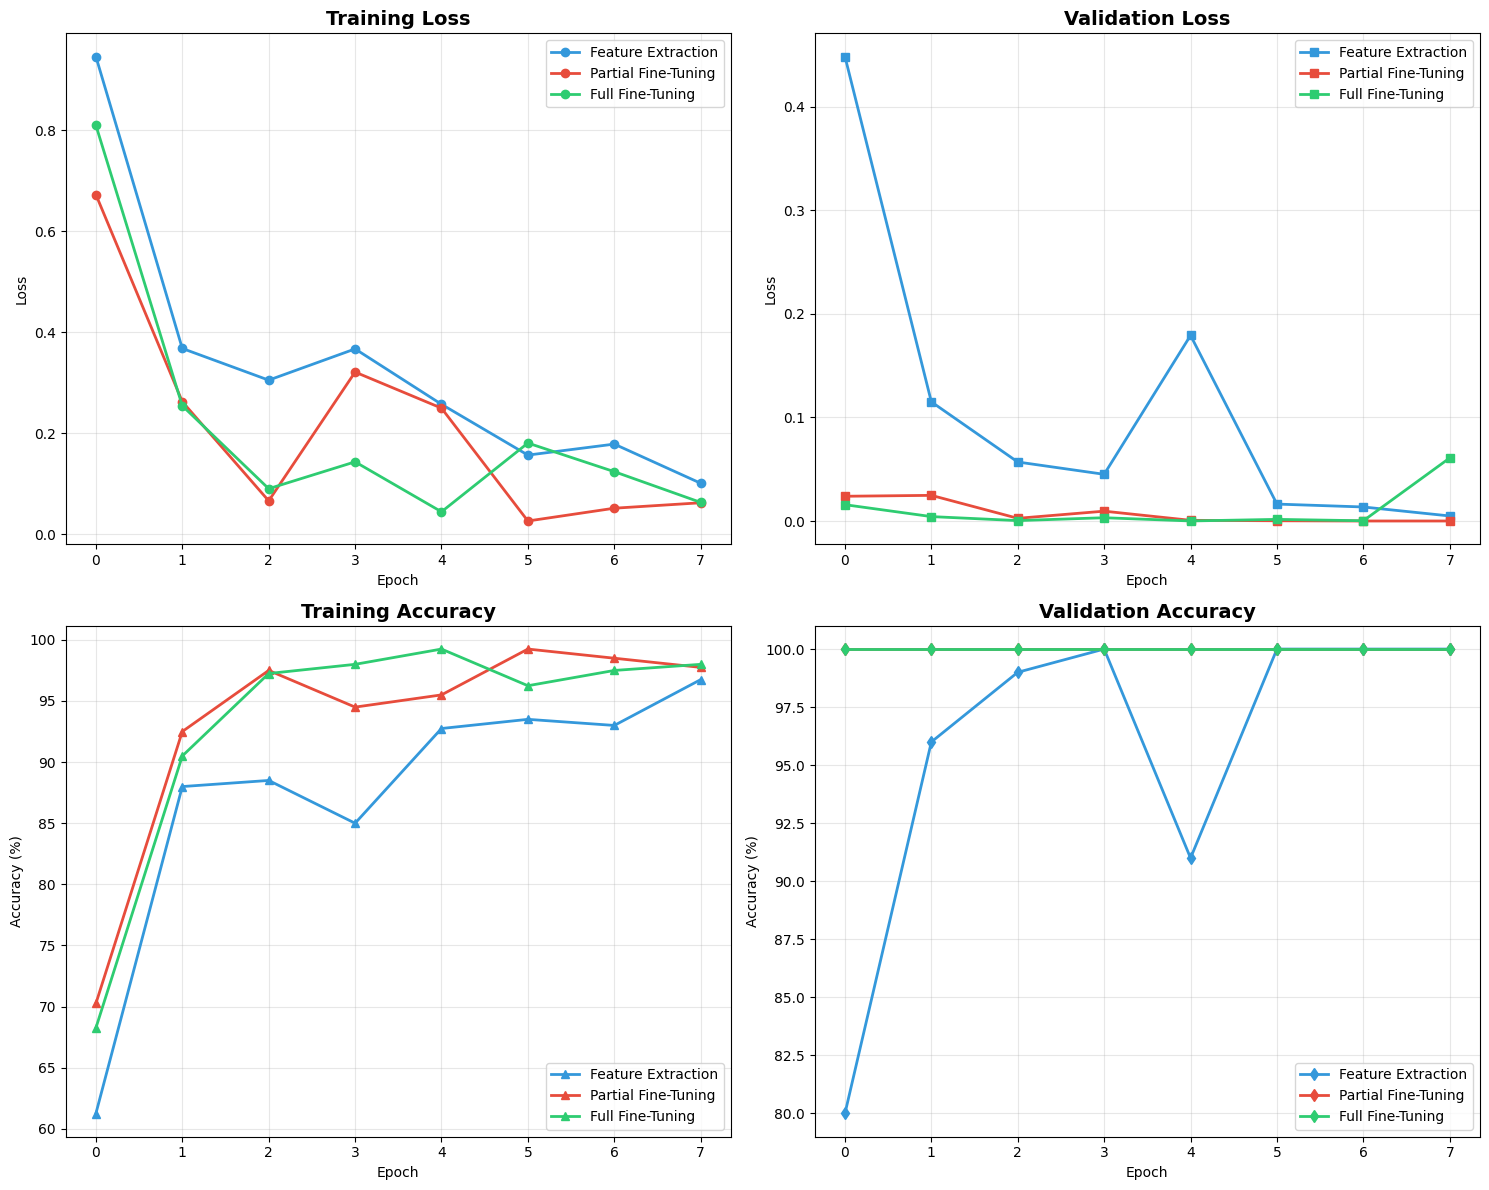

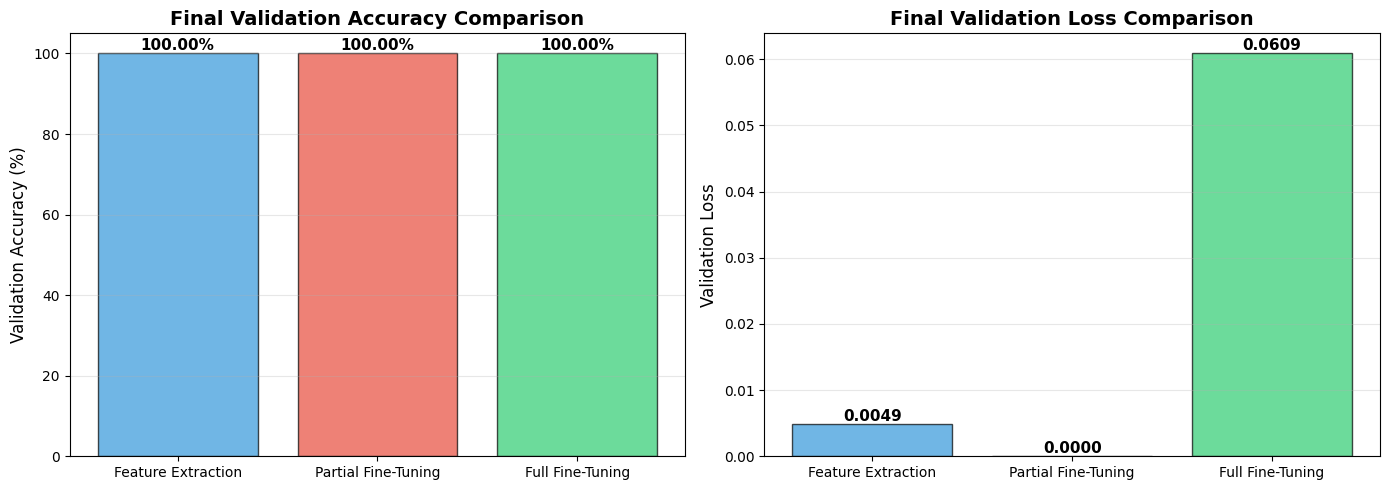

Visualization complete


In [ ]:
# 9. Visualize Training Comparison and Performance Analysis

print("\n" + "="*70)
print("VISUALIZING TRAINING COMPARISON")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

colors = {'Feature Extraction': '#3498db', 'Partial Fine-Tuning': '#e74c3c', 'Full Fine-Tuning': '#2ecc71'}

for approach, (train_losses, val_losses, train_accs, val_accs) in results.items():
    axes[0, 0].plot(train_losses, label=approach, linewidth=2, marker='o', color=colors[approach])
    axes[0, 1].plot(val_losses, label=approach, linewidth=2, marker='s', color=colors[approach])
    axes[1, 0].plot(train_accs, label=approach, linewidth=2, marker='^', color=colors[approach])
    axes[1, 1].plot(val_accs, label=approach, linewidth=2, marker='d', color=colors[approach])

axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].set_title('Validation Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

approaches = list(results.keys())
final_val_accs = [results[app][3][-1] for app in approaches]
final_val_losses = [results[app][1][-1] for app in approaches]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(approaches, final_val_accs, color=[colors[app] for app in approaches], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax1.set_title('Final Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars1, final_val_accs):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = ax2.bar(approaches, final_val_losses, color=[colors[app] for app in approaches], alpha=0.7, edgecolor='black')
ax2.set_ylabel('Validation Loss', fontsize=12)
ax2.set_title('Final Validation Loss Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, loss in zip(bars2, final_val_losses):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{loss:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualization complete")

## Code Example 3.2 (viii) Synthesizing experimental results into **actionable insights**, presents strategic trade-off analysis

### Short Description
This code synthesizes experimental results into **actionable insights**, presents strategic trade-off analysis, and demonstrates **agentic consultation** for deployment decisions. It showcases how to transform technical experiments into practical guidelines and leverage LLMs for strategic recommendations in agentic AI workflows.

### Key Libraries Used
- Built-in Python data structures (**dict, list**): Organize and present structured knowledge about transfer learning approaches  
- **matplotlib.pyplot**: Creates visual parameter efficiency comparisons  
- **Custom query_deepseek function**: Engages LLM agent for contextualized deployment recommendations  

## Code Logic and Flow
### High-Level Overview
This final section implements a comprehensive synthesis framework that transforms the experimental comparison into **actionable knowledge** for agentic AI practitioners. The workflow systematically analyzes trade-offs across multiple dimensions (time, cost, data requirements, accuracy), documents best practices distilled from experimental observations, identifies common challenges with mitigation strategies, visualizes parameter efficiency differences, and finally consults an LLM agent for contextualized deployment recommendations. This represents the complete **knowledge extraction and decision support cycle** in agentic AI development.

### Visual Flowchart
```mermaid
graph TD
    A[Start: Synthesis Phase] --> B[Define Multi-Dimensional Trade-off Matrix];
    B --> C[Display Comparative Trade-off Table];
    C --> D[Present Best Practices List];
    D --> E[Document Common Challenges];
    E --> F[Visualize Parameter Efficiency];
    
    subgraph Strategic Analysis
        B --> B1[Training Time Dimension];
        B --> B2[Compute Cost Dimension];
        B --> B3[Data Requirements Dimension];
        B --> B4[Accuracy Potential Dimension];
        B --> B5[Risk Assessment Dimension];
        B --> B6[Application Context];
    end
    
    F --> G[Formulate Deployment Scenario];
    G --> H[Query LLM for Contextual Advice];
    H --> I[Receive and Display Recommendation];
    I --> J[Summarize Key Takeaways];
    J --> K[End: Complete Learning Cycle];

    style A fill:#e1f5dd,stroke:#6b9e6b,stroke-width:2px
    style B fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style C fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style D fill:#f3e5f5,stroke:#9575b3,stroke-width:2px
    style E fill:#fce4ec,stroke:#c48b9f,stroke-width:2px
    style F fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style B1 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style B2 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style B3 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style B4 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style B5 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style B6 fill:#e8f5e9,stroke:#81a684,stroke-width:1px
    style G fill:#e1f0f5,stroke:#7d9fb8,stroke-width:2px
    style H fill:#fff4e6,stroke:#d4a373,stroke-width:2px
    style I fill:#e3f2fd,stroke:#7ba3cc,stroke-width:2px
    style J fill:#fff9e6,stroke:#d9c27a,stroke-width:2px
    style K fill:#d4edda,stroke:#6b9e6b,stroke-width:2px
```

## Step-by-Step Code Breakdown
### Step 1: Multi-Dimensional Trade-off Analysis
**Purpose:** Structures and presents the comparative advantages and limitations of each transfer learning approach across six critical decision-making dimensions.

**Key Operations:**
- Creates a nested dictionary structure mapping each approach to six evaluation metrics  
- Defines qualitative assessments for **training speed** (Fast/Moderate/Slow)  
- Specifies **compute resource requirements** (Low/Medium/High)  
- Outlines **data requirements** with concrete sample ranges (Small/Medium/Large)  
- Estimates **accuracy potential** (Moderate/High/Highest)  
- Assesses **overfitting risk levels** (Low/Moderate/High)  
- Recommends ideal **application contexts** based on domain characteristics  

### Step 2: Best Practices Documentation
**Purpose:** Distills experimental observations and theoretical knowledge into **actionable guidelines** for practitioners.

**Key Operations:**
- Presents an ordered list of **evidence-based recommendations**  
- Emphasizes **iterative development** (starting with feature extraction baselines)  
- Documents critical **hyperparameter guidance** (learning rate scaling for pre-trained layers)  
- Recommends specific technical strategies (discriminative fine-tuning, progressive unfreezing)  
- Includes validation and regularization techniques to prevent common failure modes  
- Provides a comprehensive **checklist** for successful transfer learning implementation  

### Step 3: Challenge Identification and Mitigation
**Purpose:** Anticipates common failure modes in transfer learning and provides explanations to help practitioners recognize and address them.

**Key Operations:**
- Identifies four critical challenges with concise definitions  
- Explains **"Catastrophic Forgetting"** as destruction of pre-trained features  
- Describes **"Overfitting"** as memorization of small target datasets  
- Defines **"Domain Mismatch"** as excessive difference between source and target domains  
- Highlights **"Class Imbalance"** as unequal representation across categories  

### Step 4: Parameter Efficiency Visualization
**Purpose:** Creates a visual representation of the fundamental efficiency differences between approaches.

**Key Operations:**
- Generates a bar chart comparing **trainable parameter counts** (captured earlier)  
- Converts raw parameter counts to **millions** for easier interpretation  
- Applies consistent color scheme with previous visualizations  
- Adds precise value labels on each bar for direct comparison  
- Highlights the **exponential increase** in trainable parameters across approaches  

### Step 5: Agentic Deployment Consultation
**Purpose:** Demonstrates how LLM agents can provide contextualized strategic recommendations based on specific deployment scenarios.

**Key Operations:**
- Constructs a detailed scenario prompt specifying exact constraints (**500 images per class**)  
- Requests consideration of three key decision factors: **training time, accuracy, overfitting risk**  
- Sets response constraints (4 sentences) for concise, actionable advice  
- Integrates the LLM consultation as the final step in the decision-making pipeline  
- Shows how agentic systems can combine **empirical results** with **contextual reasoning**  

## Connecting to the Lecture
- **Multi-Criteria Decision Analysis:** Implements the "multi-dimensional evaluation framework" discussed in lecture, moving beyond single-metric optimization to holistic assessment.  
- **Knowledge Synthesis Patterns:** Demonstrates "experiment-to-knowledge" transformation, a key capability for autonomous agentic systems that learn from their own experiments.  
- **Risk-Aware AI Development:** The explicit risk assessment (overfitting risk) connects to lecture discussions about "responsible and robust agentic systems."  
- **Strategic LLM Consultation:** Shows practical implementation of "LLMs as strategic advisors" in agentic workflows, providing contextualized recommendations based on empirical results.  
- **Decision Support Systems:** The complete synthesis represents a "decision support pipeline" that transforms raw experimental data into actionable deployment guidance.  
- **Parameter Efficiency Awareness:** The visualization reinforces the "computational budget consciousness" principle crucial for scalable agentic AI deployments.  
- **Complete Learning Cycle:** The section embodies the "full agentic development cycle": **experiment → analyze → synthesize → recommend → deploy**.  
- **Practical Knowledge Transfer:** The best practices list demonstrates "knowledge codification" from specific experiments to general guidelines, enabling knowledge transfer across agentic AI projects.  



TRANSFER LEARNING BEST PRACTICES AND TRADE-OFFS

TRADE-OFFS COMPARISON:
----------------------------------------------------------------------------------------------------
Approach                  Training Time   Compute Cost    Data Required        Accuracy       
----------------------------------------------------------------------------------------------------
Feature Extraction        Fast            Low             Small (100-1000)     Moderate       
Partial Fine-Tuning       Moderate        Medium          Medium (1000-10000)  High           
Full Fine-Tuning          Slow            High            Large (10000+)       Highest        
----------------------------------------------------------------------------------------------------

BEST PRACTICES:
1. Start with feature extraction for quick baseline
2. Use lower learning rates for pre-trained layers (10-100x smaller)
3. Apply data augmentation to prevent overfitting
4. Monitor validation metrics to detect overfitting earl

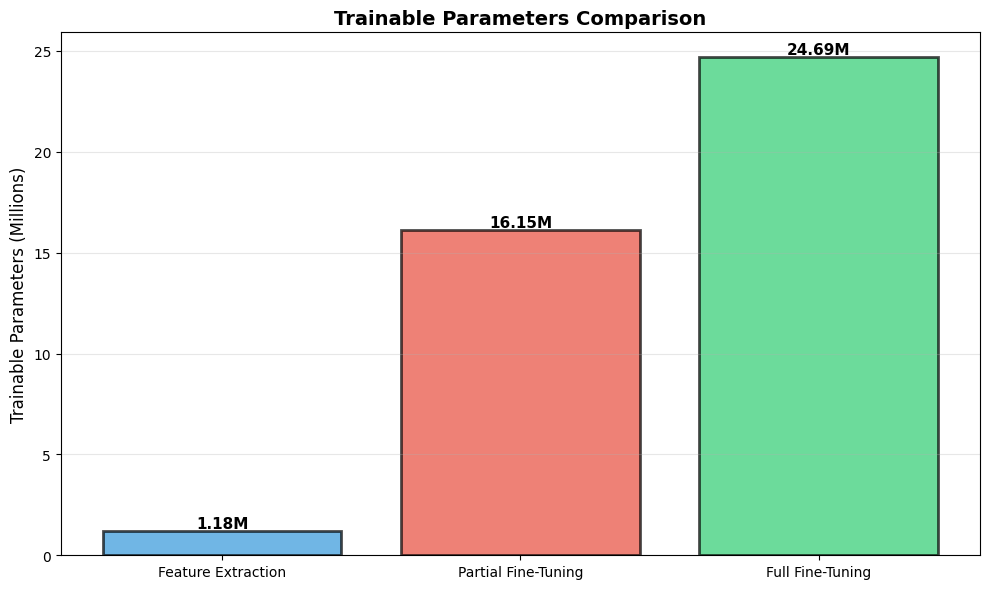


DeepSeek Deployment Recommendation:
Error: 401 - {"error":{"message":"Authentication Fails, Your api key: None is invalid","type":"authentication_error","param":null,"code":"invalid_request_error"}}

EXERCISE COMPLETE
Key Takeaways:
1. Transfer learning leverages pre-trained models for faster training and better accuracy
2. Feature extraction is fast but may underfit on domain-shifted data
3. Partial fine-tuning balances adaptation and training efficiency
4. Full fine-tuning achieves highest accuracy but requires more data and compute
5. Use lower learning rates for pre-trained layers to avoid catastrophic forgetting
6. Choose approach based on dataset size, domain similarity, and compute budget


In [ ]:
# 10. Best Practices, Trade-offs Analysis, and Deployment Recommendations

print("\n" + "="*70)
print("TRANSFER LEARNING BEST PRACTICES AND TRADE-OFFS")
print("="*70)

tradeoffs_data = {
    'Feature Extraction': {
        'Training Time': 'Fast',
        'Compute Cost': 'Low',
        'Data Required': 'Small (100-1000)',
        'Accuracy Potential': 'Moderate',
        'Overfitting Risk': 'Low',
        'Best For': 'Similar domain, limited data'
    },
    'Partial Fine-Tuning': {
        'Training Time': 'Moderate',
        'Compute Cost': 'Medium',
        'Data Required': 'Medium (1000-10000)',
        'Accuracy Potential': 'High',
        'Overfitting Risk': 'Moderate',
        'Best For': 'Moderate domain shift'
    },
    'Full Fine-Tuning': {
        'Training Time': 'Slow',
        'Compute Cost': 'High',
        'Data Required': 'Large (10000+)',
        'Accuracy Potential': 'Highest',
        'Overfitting Risk': 'High',
        'Best For': 'Large dataset, significant domain shift'
    }
}

print("\nTRADE-OFFS COMPARISON:")
print("-" * 100)
print(f"{'Approach':<25} {'Training Time':<15} {'Compute Cost':<15} {'Data Required':<20} {'Accuracy':<15}")
print("-" * 100)
for approach, metrics in tradeoffs_data.items():
    print(f"{approach:<25} {metrics['Training Time']:<15} {metrics['Compute Cost']:<15} "
          f"{metrics['Data Required']:<20} {metrics['Accuracy Potential']:<15}")
print("-" * 100)

print("\nBEST PRACTICES:")
best_practices = [
    "1. Start with feature extraction for quick baseline",
    "2. Use lower learning rates for pre-trained layers (10-100x smaller)",
    "3. Apply data augmentation to prevent overfitting",
    "4. Monitor validation metrics to detect overfitting early",
    "5. Use layer-wise learning rates (discriminative fine-tuning)",
    "6. Freeze batch normalization layers during fine-tuning",
    "7. Gradually unfreeze layers (progressive unfreezing)",
    "8. Use appropriate regularization (dropout, weight decay)"
]
for practice in best_practices:
    print(practice)

print("\nCOMMON CHALLENGES:")
challenges = {
    'Catastrophic Forgetting': 'Pre-trained features destroyed by high learning rates',
    'Overfitting': 'Model memorizes small target dataset',
    'Domain Mismatch': 'Source and target domains too different',
    'Class Imbalance': 'Unequal samples per class in target dataset'
}
for challenge, description in challenges.items():
    print(f"  {challenge}: {description}")

# Use the saved trainable parameters comparison from earlier
fig, ax = plt.subplots(figsize=(10, 6))
approaches_list = list(trainable_params_comparison.keys())
params_millions = [trainable_params_comparison[app] / 1e6 for app in approaches_list]
bars = ax.bar(approaches_list, params_millions, color=[colors[app] for app in approaches_list],
              alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Trainable Parameters (Millions)', fontsize=12)
ax.set_title('Trainable Parameters Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, param in zip(bars, params_millions):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{param:.2f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

deployment_recommendation = query_deepseek(
    "For a flower classification app with 500 training images per class, which transfer learning "
    "approach (feature extraction, partial fine-tuning, or full fine-tuning) would you recommend "
    "and why? Consider training time, accuracy, and overfitting risk. Answer in 4 sentences."
)
print("\nDeepSeek Deployment Recommendation:")
print(deployment_recommendation)

print("\n" + "="*70)
print("EXERCISE COMPLETE")
print("="*70)
print("Key Takeaways:")
print("1. Transfer learning leverages pre-trained models for faster training and better accuracy")
print("2. Feature extraction is fast but may underfit on domain-shifted data")
print("3. Partial fine-tuning balances adaptation and training efficiency")
print("4. Full fine-tuning achieves highest accuracy but requires more data and compute")
print("5. Use lower learning rates for pre-trained layers to avoid catastrophic forgetting")
print("6. Choose approach based on dataset size, domain similarity, and compute budget")